In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x)else x)

c:\Users\heroj\anaconda3\envs\proyecto_python1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_DA_ch= df[(df['job_title_short']== 'Data Analyst') & (df['job_country'] == 'Chile')].copy()

df_DA_ch = df_DA_ch.dropna(subset=['salary_year_avg'])

<Axes: >

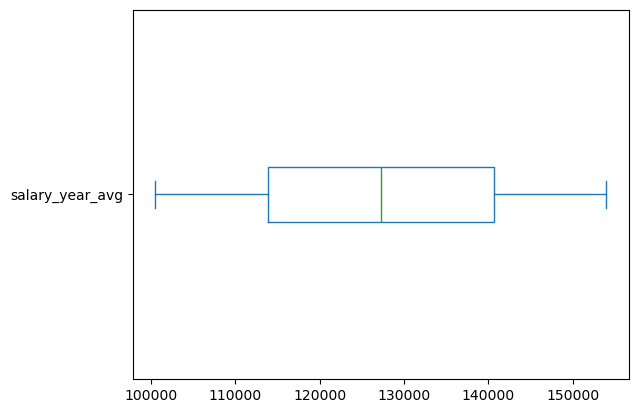

In [5]:
df_DA_ch['salary_year_avg'].plot(kind='box', vert = False)

C:\Users\heroj\AppData\Local\Temp\ipykernel_20964\3297463253.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False )


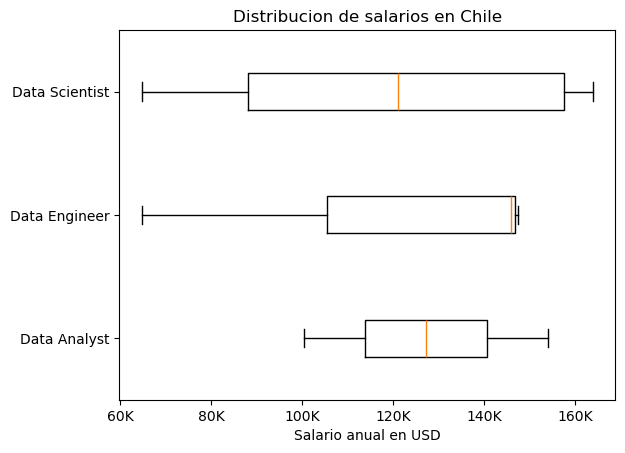

In [10]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_ch= df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'Chile')].copy()
df_ch= df_ch.dropna(subset=['salary_year_avg'])

job_list= [df_ch[df_ch['job_title_short']== job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False )
plt.title('Distribucion de salarios en Chile')
plt.xlabel('Salario anual en USD')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))
plt.show()